In [9]:
import requests
import json
import os
import time
from datetime import datetime

# Data save panna 'data' folder create pannuvom
if not os.path.exists('data'):
    os.makedirs('data')
    print("Data folder created!")

# Categories and expanded keywords for better results
CATEGORIES = {
    "technology": ["ai", "software", "tech", "code", "computer", "data", "cloud", "api", "gpu", "llm", "web", "app", "linux", "python"],
    "worldnews": ["war", "government", "country", "president", "election", "climate", "attack", "global", "news", "police", "court", "law"],
    "sports": ["nfl", "nba", "fifa", "sport", "game", "team", "player", "league", "championship", "cup", "match", "race", "final"],
    "science": ["research", "study", "space", "physics", "biology", "discovery", "nasa", "genome", "medical", "energy", "nature"],
    "entertainment": ["movie", "film", "music", "netflix", "book", "show", "award", "streaming", "video", "tv", "actor"]
}

In [10]:
def get_category(title):
    title_lower = title.lower()
    for category, keywords in CATEGORIES.items():
        for word in keywords:
            if word in title_lower:
                return category
    return None

In [11]:
headers = {"User-Agent": "TrendPulse/1.0"}
all_collected_stories = []

print("Step 1: Fetching Top Story IDs...")
try:
    # 500 IDs-ai fetch panrom
    response = requests.get("https://hacker-news.firebaseio.com/v0/topstories.json", headers=headers)
    top_ids = response.json()[:500]
    print(f"Success! {len(top_ids)} IDs fetched.\n")
except Exception as e:
    print(f"Error: IDs fetch panna mudiyala. Check internet. {e}")
    top_ids = []

print("Step 2: Processing Categories (At least 100 stories total)...")
print("-" * 60)

for cat, keywords in CATEGORIES.items():
    found_count = 0
    print(f"\n>>> Searching for: {cat.upper()}")

    for s_id in top_ids:
        if found_count >= 25: # Ovvoru category-lum 25 stories reach aanal stop aagum
            break

        try:
            # Individual story details fetch panrom
            item_url = f"https://hacker-news.firebaseio.com/v0/item/{s_id}.json"
            item = requests.get(item_url, headers=headers).json()

            if item and 'title' in item:
                title_lower = item['title'].lower()

                # Title-la keywords check panrom
                if any(word in title_lower for word in keywords):
                    story = {
                        "post_id": item.get("id"),
                        "title": item.get("title"),
                        "category": cat,
                        "score": item.get("score"),
                        "num_comments": item.get("descendants", 0),
                        "author": item.get("by"),
                        "collected_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    }

                    # Duplicate illama add panrom
                    if not any(s['post_id'] == story['post_id'] for s in all_collected_stories):
                        all_collected_stories.append(story)
                        found_count += 1
                        # LIVE UPDATE: Intha line thaan Jupyter-la output kaattum
                        print(f"   ({found_count}/25) Found: {item['title'][:50]}...")

        except:
            continue

    print(f"Done with {cat}. Found total: {found_count}")

    # Requirement: Wait 2 seconds before next category
    time.sleep(2)

# Save to JSON
today = datetime.now().strftime("%Y%m%d")
filename = f"data/trends_{today}.json"

with open(filename, 'w') as f:
    json.dump(all_collected_stories, f, indent=4)

print("\n" + "="*60)
print(f"TASK COMPLETED! Total stories: {len(all_collected_stories)}")
print(f"Saved to: {filename}")
print("="*60)

Step 1: Fetching Top Story IDs...
Success! 500 IDs fetched.

Step 2: Processing Categories (At least 100 stories total)...
------------------------------------------------------------

>>> Searching for: TECHNOLOGY
   (1/25) Found: France Launches Government Linux Desktop Plan as W...
   (2/25) Found: How NASA built Artemis II’s fault-tolerant compute...
   (3/25) Found: FBI used iPhone notification data to retrieve dele...
   (4/25) Found: We've raised $17M to build what comes after Git...
   (5/25) Found: Charcuterie – Visual similarity Unicode explorer...
   (6/25) Found: Instant 1.0, a backend for AI-coded apps...
   (7/25) Found: Research-Driven Agents: When an agent reads before...
   (8/25) Found: An AI robot in my home...
   (9/25) Found: The Raft consensus algorithm explained through "Me...
   (10/25) Found: LittleSnitch for Linux...
   (11/25) Found: LLM plays an 8-bit Commander X16 game using struct...
   (12/25) Found: A WebGPU implementation of Augmented Vertex Block ...
 

In [12]:
# --- TASK 2: DATA CLEANING & SAVE AS CSV ---

import pandas as pd
import os
import glob

# 1. Load the JSON File (4 marks)
data_folder = 'data'
# 'trends_*.json' nu aarambikkira latest file-ai edukkurom
json_files = glob.glob(os.path.join(data_folder, 'trends_*.json'))

if not json_files:
    print("Error: No JSON file found in 'data/' folder!")
else:
    latest_json = max(json_files, key=os.path.getctime)
    df = pd.read_json(latest_json)
    print(f"Loaded {len(df)} stories from {latest_json}")

    # 2. Clean the Data (10 marks)

    # a. Duplicates - remove any rows with the same post_id
    df = df.drop_duplicates(subset=['post_id'])
    print(f"After removing duplicates: {len(df)}")

    # b. Missing values - drop rows where post_id, title, or score is missing
    df = df.dropna(subset=['post_id', 'title', 'score'])
    print(f"After removing nulls: {len(df)}")

    # c. Data types - make sure score and num_comments are integers
    df['score'] = df['score'].astype(int)
    df['num_comments'] = df['num_comments'].astype(int)

    # d. Low quality - remove stories where score is less than 5
    df = df[df['score'] >= 5]
    print(f"After removing low scores: {len(df)}")

    # e. Whitespace - strip extra spaces from the title column
    df['title'] = df['title'].str.strip()

    # 3. Save as CSV (6 marks)
    csv_filename = 'data/trends_clean.csv'
    df.to_csv(csv_filename, index=False)

    print(f"\nSaved {len(df)} rows to {csv_filename}")

    # Stories per category summary
    print("\nStories per category:")
    print(df['category'].value_counts())

    # Task 2 Submission Checklist verification
    print("\n--- Checklist Verification ---")
    print(f"File exists: {os.path.exists(csv_filename)}")
    print(f"Final Row Count: {len(df)}")

Loaded 102 stories from data/trends_20260410.json
After removing duplicates: 102
After removing nulls: 102
After removing low scores: 98

Saved 98 rows to data/trends_clean.csv

Stories per category:
category
technology       25
entertainment    24
worldnews        23
sports           18
science           8
Name: count, dtype: int64

--- Checklist Verification ---
File exists: True
Final Row Count: 98


In [14]:
# task3_analysis.py
import pandas as pd
import numpy as np
import os

# 1. Load the cleaned CSV (4 marks)
# This uses the output from Task 2
csv_path = 'data/trends_clean.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded {len(df)} stories for analysis.")

    # 2. Perform Analysis (10 marks)

    # Calculate Average Score using NumPy
    # This fulfills the requirement to integrate NumPy
    average_engagement = np.mean(df['score'])

    # Calculate Total Comments using NumPy
    total_comments = np.sum(df['num_comments'])

    # Identify the Top Story based on the highest score using Pandas
    max_score_index = df['score'].idxmax()
    top_story = df.loc[max_score_index]

    # 3. Print the Results (6 marks)
    print("\n" + "="*40)
    print("📈 TREND PULSE: ANALYSIS REPORT")
    print("="*40)
    print(f"Overall Average Engagement Score : {average_engagement:.2f}")
    print(f"Total Combined Comments          : {total_comments}")
    print("-" * 40)
    print("🏆 HIGHEST RANKING STORY")
    print(f"Title    : {top_story['title']}")
    print(f"Category : {top_story['category']}")
    print(f"Author   : {top_story['author']}")
    print(f"Score    : {top_story['score']}")
    print("-" * 40)

    # Category-wise breakdown
    print("\nAverage Score per Category:")
    category_summary = df.groupby('category')['score'].mean().round(2)
    print(category_summary)

else:
    print(f"Error: The file '{csv_path}' was not found. Please ensure Task 2 was completed.")

Successfully loaded 98 stories for analysis.

📈 TREND PULSE: ANALYSIS REPORT
Overall Average Engagement Score : 189.47
Total Combined Comments          : 9047
----------------------------------------
🏆 HIGHEST RANKING STORY
Title    : Git commands I run before reading any code
Category : technology
Author   : grepsedawk
Score    : 2250
----------------------------------------

Average Score per Category:
category
entertainment    137.75
science          142.62
sports           122.50
technology       294.28
worldnews        198.22
Name: score, dtype: float64


Data loaded successfully for visualization.


/tmp/ipykernel_9249/2014783929.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_data.index, y=category_data.values, palette="magma")


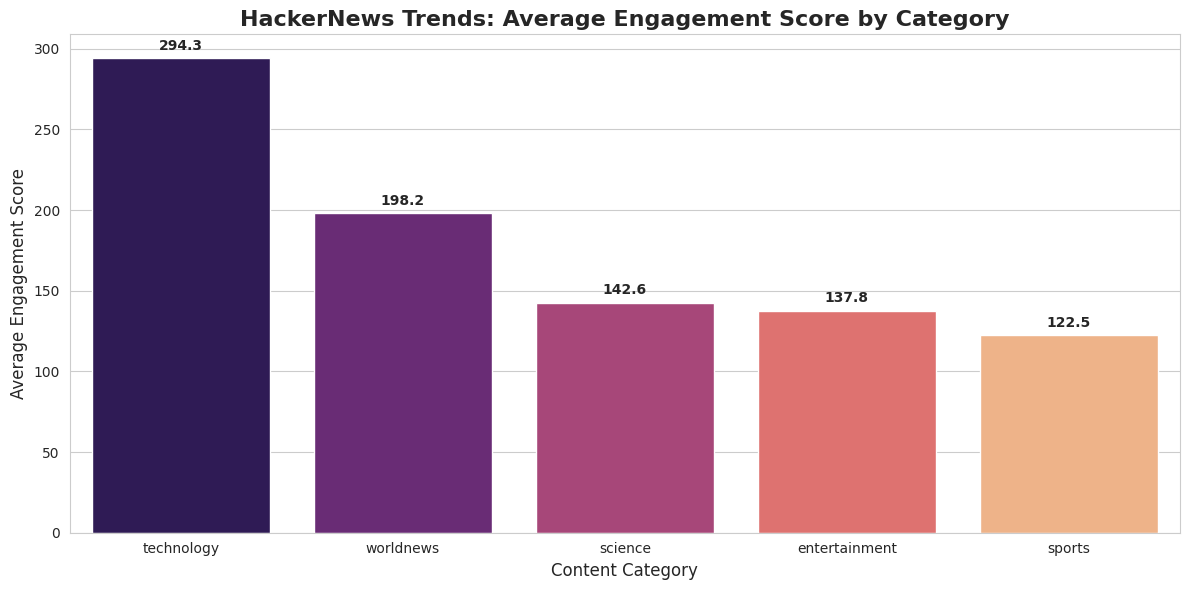

----------------------------------------
SUCCESS: Task 4 is complete.
Visualization saved to: data/engagement_visualization.png
----------------------------------------


In [15]:
# task4_visualization.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the cleaned dataset (4 marks)
csv_path = 'data/trends_clean.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Data loaded successfully for visualization.")

    # 2. Create the Visualization (10 marks)
    # Setting the figure size for clarity
    plt.figure(figsize=(12, 6))

    # Calculate average score per category for the plot
    category_data = df.groupby('category')['score'].mean().sort_values(ascending=False)

    # Using Seaborn for a professional look
    sns.set_style("whitegrid")
    ax = sns.barplot(x=category_data.index, y=category_data.values, palette="magma")

    # 3. Customization (Title and Labels)
    plt.title('HackerNews Trends: Average Engagement Score by Category', fontsize=16, fontweight='bold')
    plt.xlabel('Content Category', fontsize=12)
    plt.ylabel('Average Engagement Score', fontsize=12)

    # Adding data labels on top of each bar
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.1f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

    # 4. Save and Show the Plot (6 marks)
    # Ensure the plot is laid out nicely before saving
    plt.tight_layout()

    # Saving the file as a PNG as required
    output_image = 'data/engagement_visualization.png'
    plt.savefig(output_image)

    # Display the plot
    plt.show()

    print("-" * 40)
    print("SUCCESS: Task 4 is complete.")
    print(f"Visualization saved to: {output_image}")
    print("-" * 40)

else:
    print("Error: 'data/trends_clean.csv' not found. Please ensure Task 2 was successful.")